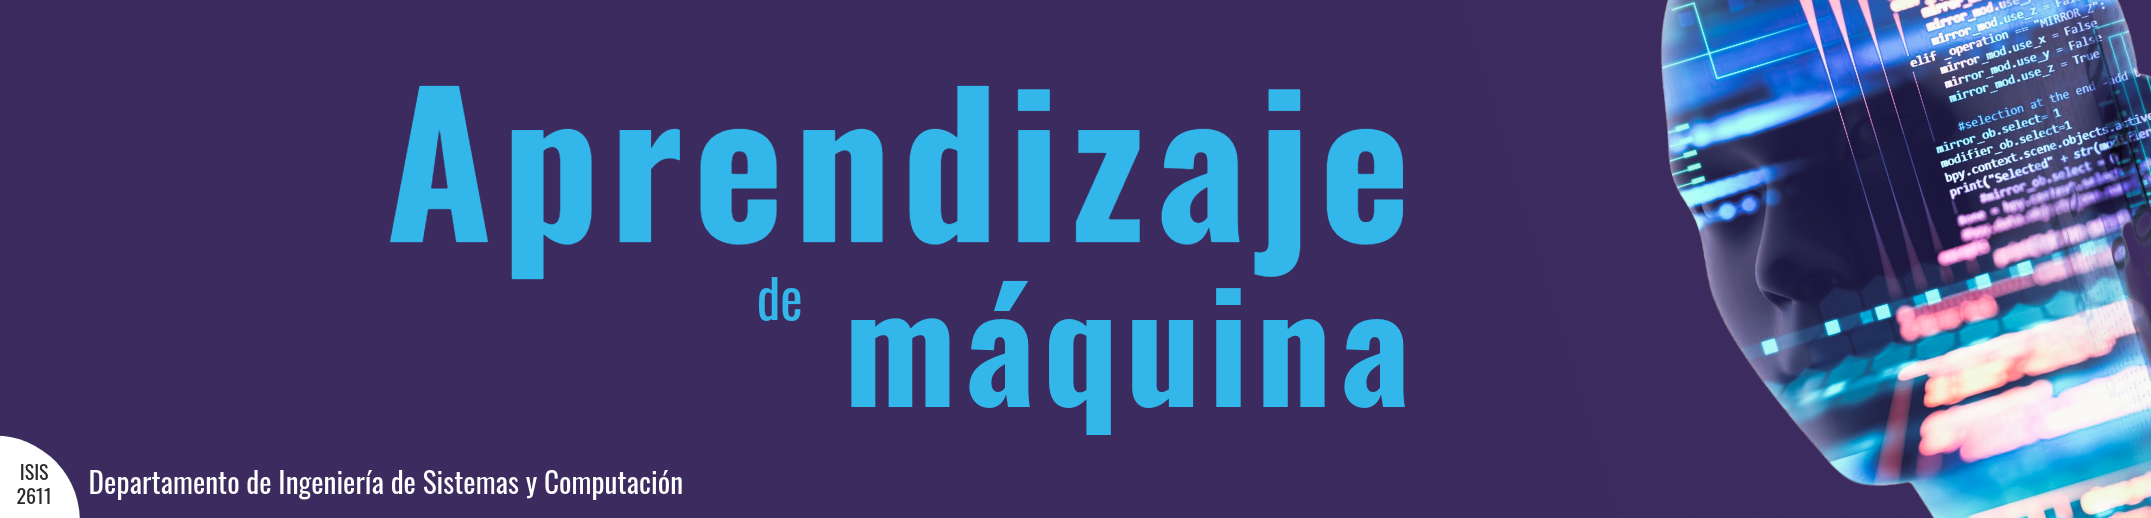

# Árboles de Decisión

En esta práctica exploraremos el uso de los Árboles de Decisión en tareas de clasificación. Estos modelos se distinguen por ser clasificadores multiclase nativos, capaces de gestionar múltiples categorías de forma directa. Su arquitectura se basa en la partición recursiva del espacio de características mediante nodos de decisión, los cuales evalúan condiciones sobre las variables del conjunto de datos. Al aplicar sucesivamente estas reglas simples, el modelo logra descomponer problemas de alta dimensionalidad en una estructura jerárquica, permitiendo aproximar fronteras de decisión no lineales con un nivel de interpretabilidad superior a otros modelos de caja negra.

Se utilizará el [Smart Mobility traffic Dataset](https://www.kaggle.com/datasets/ziya07/smart-mobility-traffic-dataset?select=smart_mobility_dataset.csv), un conjunto de datos orientado al análisis y optimización de la movilidad en entornos de ciudades inteligentes. Este conjunto integra distintos tipos de variables, como estadísticas de tráfico, reportes de accidentes, condiciones climáticas y niveles de emisiones vehiculares, con el objetivo de predecir el nivel de congestión del tráfico. De esta manera, permite analizar cómo factores heterogéneos del entorno urbano influyen en la eficiencia y el funcionamiento del sistema de transporte.

Se seguirá una estructura similar a la de las anteriores prácticas: exploración, limpieza y preparación de datos, construcción de un pipeline,  búsqueda de hiperparámetros y evaluación.

Este material está dividido en las siguientes partes:

1. Importación de librerías
2. Carga de los datos.
3. Exploración de los datos.
4. Limpieza y preparación inicial de los datos.
5. Partición de los datos.
6. Construcción del pipeline de procesamiento y modelado.
7. Entrenamiento del Árbol de decisión con búsqueda de hiperparámetros.
8. Evaluación del mejor modelo.
9. Persistencia del pipeline entrenado.
10. Ejercicios


## 1. Importación de librerías


In [ ]:
import os
import joblib
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Carga de los datos


In [ ]:
datos_movility = pd.read_csv(os.path.join('.', 'data', 'smart_mobility_dataset.csv'))

In [ ]:
data = datos_movility.copy()

El diccionario de los datos es el siguiente:

| Variable               | Tipo       | Descripción                                                      | Unidad / Escala     |
|:-----------------------|:-----------|:-----------------------------------------------------------------|:--------------------|
| Timestamp              | Temporal   | Marca temporal del registro del sistema de monitoreo de tráfico.| Fecha-hora          |
| Latitude               | Numérica   | Latitud geográfica del punto donde se registró la medición.     | Grados decimales    |
| Longitude              | Numérica   | Longitud geográfica del punto donde se registró la medición.    | Grados decimales    |
| Vehicle_Count          | Numérica   | Número de vehículos detectados por sensores.                    | Conteo de vehículos |
| Traffic_Speed_kmh      | Numérica   | Velocidad promedio del tráfico.                                 | km/h                |
| Road_Occupancy_%       | Numérica   | Porcentaje de ocupación de la vía (0–100).                      | %                   |
| Traffic_Light_State    | Categórica | Estado del semáforo cercano (Red, Yellow, Green).               | Estado semáforo     |
| Weather_Condition      | Categórica | Condiciones meteorológicas (Clear, Rain, Fog, Snow).            | Condición climática |
| Accident_Report        | Binaria    | Indica si se reportó un accidente (1 = Sí, 0 = No).             | Indicador           |
| Sentiment_Score        | Numérica   | Puntaje de sentimiento sobre el tráfico (-1, 1).                | Escala sentimiento  |
| Ride_Sharing_Demand    | Numérica   | Solicitudes de transporte compartido.                           | Conteo solicitudes  |
| Parking_Availability   | Numérica   | Espacios de estacionamiento disponibles.                        | Espacios            |
| Emission_Levels_g_km   | Numérica   | Nivel estimado de emisiones vehiculares.                        | g/km                |
| Energy_Consumption_L_h | Numérica   | Consumo energético estimado.                                    | L/h                 |
| Traffic_Condition      | Categórica | Clasificación del nivel de tráfico (Low, Medium, High).         | Nivel congestión    |

## 3. Exploración del conjunto de datos


In [ ]:
data.shape

Se identifica que el dataset está compuesto por 5000 registros, con 15 variables que lo describen.

In [ ]:
data.head()

#### Verificación de Consistencia y Validez

In [ ]:
data.describe()

In [ ]:
data['Traffic_Light_State'].value_counts()

In [ ]:
data['Weather_Condition'].value_counts()

#### Verificación de Completitud

In [ ]:
data.isnull().sum()/len(data) * 100

#### Verificación de Unicidad

In [ ]:
duplicate_percentage = data.duplicated().sum()/len(data) * 100

print(f'Porcentaje de datos completamente duplicados: {duplicate_percentage:.3f}%')

In [ ]:
duplicate_percentage_without_timestamp  = data.iloc[:, 1:].duplicated().sum()/len(data) * 100

print(f'Porcentaje de datos duplicados si no se tiene en cuenta el timestamp: {duplicate_percentage_without_timestamp:.3f}%')


Nuestra variable objetivo es `Traffic_Condition`. Podemos mostrar y visualizar en qué proporción se persentan las clases:


In [ ]:
data['Traffic_Condition'].value_counts().to_frame('conteo')\
    .assign(porcentaje=lambda x: (x['conteo']/x['conteo'].sum()*100).round(2))

In [ ]:
# Tamaño de la gráfica
plt.figure(figsize=(12,4))

# Cantidad de apariciones de cada año de construcción
plot_data = data['Traffic_Condition'].value_counts()

# Valores únicos (años) y sus frecuencias
x = plot_data.index
y = plot_data.values

# Gráfico de barras
plt.bar(x,y)

# Títulos de los ejes y del gráfico
plt.xlabel("Nivel de congestión del tráfico")
plt.ylabel("Fecuencia")
plt.title('Distribución del nivel de congestión del tráfico')

# Mostrar la gráfica
plt.show()

### Análisis de calidad


El conjunto de datos muestra buenas condiciones para su uso. En términos de completitud, no se encontraron valores ausentes en ninguna de las variables. Respecto a la unicidad, no se detectaron registros duplicados ni repeticiones en la combinación de variables que identifican los eventos de medición. En cuanto a la validez, todos los valores se encuentran dentro de los rangos esperados para sus respectivas variables, sin valores negativos o fuera de dominio. Desde el punto de vista de la consistencia, no se observaron valores contradictorios en las variables. Sin embargo, se identificó un desbalance en la variable objetivo `Traffic_Condition`, donde la categoría `High` representa aproximadamente el 63% de los registros, mientras que `Medium` corresponde a cerca del 30% y `Low`a solo el 7%. Este desbalance podría impactar en el rendimiento del modelo sobre la clase minoritaria. 


## 4. Limpieza y preparación inicial de los datos

La exploración de datos no reveló problemas de calidad que deban ser corregidos, por lo que el dataset puede ser utilizado en su estado actual.


## 5. Partición de los datos



In [ ]:
x = data.drop(columns=['Traffic_Condition'])
y = data['Traffic_Condition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


Para manterner la misma proporción de las clases en ambos conjuntos se utiliza la opción `stratify=y`.


## 6. Construcción del pipeline

Para la construcción del pipeline se comienza por eliminar aquellas variables que no aportan información significativa para resolver el problema de clasificación. En este caso las variables de `Timestamp`, `Latitude`, y `Longitude` se pueden eliminar, ya que su inclusión podría inducir un sesgo espacio-temporal que limitaría la capacidad de generalización del modelo. El objetivo es que el clasificador aprenda a identificar estados de congestión con base en la dinámica del tráfico y factores ambientales. 

Ahora bien, aunque es posible crear una función para eliminar explícitamente las variables no deseadas, esto no es necesario cuando se utiliza `ColumnTransformer`. Por defecto, este componente solo mantiene las columnas a las que se les aplica alguna transformación (remainder='drop') y elimina automáticamente las demás. Por lo tanto, no se requiere incluir un paso adicional en el pipeline para eliminar variables que no se desean utilizar en el modelo. Entonces, solo se creeará una lista con variables a eliminar para poder depurar las variables numéricas y categóricas posteriormente. 


In [ ]:
cols_to_drop = ['Timestamp', 'Latitude', 'Longitude']

Se separan las variables numéricas de las categóricas para poder aplicar las transformaciones correspondientes a cada tipo de variable.

In [ ]:
categorical_features = X_train.select_dtypes(include=['object']).columns.drop(cols_to_drop, errors="ignore")
numerical_features = X_train.select_dtypes(include=['number']).columns.drop(cols_to_drop, errors="ignore")


Aunque el uso de `StandardScaler()` es una práctica estándar para homogeneizar rangos y evitar sesgos de magnitud, su utilización no es necesaria para los algoritmos de Árboles de Decisión. A diferencia de los basados en distancias o gradientes, los árboles son invariantes a la escala. Debido a que sus particiones se basan en criterios de pureza como la entropía o el índice Gini, el modelo identifica umbrales de decisión óptimos independientemente de la magnitud absoluta de las variables, lo que hace que este preprocesamiento sea innecesario.


Para las variables categóricas sigue siendo recomendado utilizar `OneHotEncoder()`:

In [ ]:
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    drop='if_binary'
)


Una vez con las transformaciones definidas para las variables categóricas, se utiliza `ColumnTransformer()` para aplicar estas transformaciones. No obstante, vale la pena mencionar que como las variables numéricas no requieren transformaciones, se utiliza el string `'passthrough'` para indicar que las variables numéricas no se deberian eliminar.


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', 'passthrough', numerical_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)


A continuación, se crea el pipeline final. Este estará compuesto del preprocesador previamente definido, y del Árbol de Decisión como modelo de clasificación.


In [ ]:
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

## 7. Entrenamiento del modelo de Árbol de Decisión con búsqueda de hiperparámetros



Los hiperparámetros de los Árboles de Decisión se dividen en dos categorías fundamentales: aquellos que definen el criterio de partición para identificar umbrales de decisión óptimos, y aquellos que regulan la topología del modelo. Parámetros como la profundidad máxima, o el máximo número dehojas, controlan la complejidad del árbol. En esta sección, se realizará una búsqueda de hiperparámetros para encontrar la configuración que maximice la capacidad de generalización del árbol.

In [ ]:
param_grid = [
    {   # Hiperparámetros del criterio de partición
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__splitter': ['best', 'random'],
        'model__max_features': ['sqrt', 'log2', None],

        # Hiperparámetros de complejidad del árbol
        'model__max_depth': [5, 10, 15],
        'model__max_leaf_nodes': [3, 9, 18, 27]
    }
]


Por otro lado, definiremos un objeto de la clase `KFold()` con el objetivo de realizar la validación cruzada, es el mismo que usamos en la práctica anterior, nuevamente especificamos 10 subconjuntos con el parámetro `n_splits` y usamos el `shuffle` para reordenar el conjunto de datos en cada iteración.


In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)


Para la búsqueda de hiperparámetros se empleará `GridSearchCV()` utilizando como métrica el `F1-score`. Dado que se trata de un problema de clasificación multiclase, se va a utilizar un método de promediado; en este caso se utilizará `f1_weighted`, que pondera el desempeño de cada clase según su frecuencia en el conjunto de datos. No obstante, es importante tener en cuenta que esta métrica otorgará mayor peso a las clases mayoritarias. En contextos donde el costo de no detectar una congestión alta (falso negativo) sea especialmente crítico, podría considerarse el uso de `f1_macro`, que asigna el mismo peso a todas las clases, o incluso el diseño de una matriz de costos personalizada, con el fin de evitar que las clases menos frecuentes queden subrepresentadas en la evaluación del modelo.


In [ ]:
decision_tree_grid = GridSearchCV(estimator=decision_tree_pipeline, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

In [ ]:
decision_tree_grid.fit(X_train, y_train)


Se exploran los resultados obtenidos de la búsqueda:


In [ ]:
print('Mejores hiperparámetros:\n')
display(decision_tree_grid.best_params_)
print(f'\nMejor puntaje medio en CV: {decision_tree_grid.best_score_:.3f}')


Se genera un reporte del desempeño de cada combinación de hiperparámetros evaluada mediante validación cruzada.


In [ ]:
results = pd.DataFrame(decision_tree_grid.cv_results_)
cols = [
    'param_model__criterion',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = results[cols].sort_values(by='rank_test_score')
display(summary)

## 8. Evaluación del mejor modelo

Ahora se utilizará el mejor modelo encontrado durante el proceso de `GridSearch`, almacenado en best_model, para aplicar el pipeline completo al conjunto de prueba para evaluar su desempeño.

In [ ]:
best_model = decision_tree_grid.best_estimator_

In [ ]:
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))


El reporte de evaluación sobre el conjunto de prueba muestra un desempeño prácticamente perfecto del modelo. La exactitud (accuracy) alcanza el valor de 1.00, lo que indica que el modelo clasifica correctamente casi todos los registros del conjunto de test. A nivel de clases individuales, tanto High como Medium presentan valores de precisión, recall y F1-score iguales a 1.00, lo que significa que el modelo identifica correctamente todos los casos de estas categorías sin generar falsos positivos ni falsos negativos. En el caso de la clase Low, el desempeño también es muy alto, con un recall de 0.99, lo que sugiere que solo un número muy pequeño de instancias de esta clase no fue correctamente identificado.

Adicionalmente, tanto el promedio macro como el promedio ponderado del F1-score son iguales a 1.00, lo cual indica que el desempeño del modelo se mantiene incluso considerando el desbalance entre las clases (especialmente la menor representación de la clase Low). En conjunto, estos resultados sugieren que el modelo logra distinguir adecuadamente los distintos niveles de congestión del tráfico en los datos de prueba. No obstante, dado que las métricas son casi perfectas, sería recomendable verificar que no existan variables altamente derivadas de la variable objetivo.



Para entrar a detalle sobre los resultados del reporte de clasificación, se utiliza la matriz de confusión correspondiente las predicciones del conjunto de evaluación.


In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.show()

La matriz revela que, de todo el conjunto de evaluación, el modelo clasificó erróneamente tan solo uno de los datos, el cual debía ser clasificado como `Low`, pero fue clasificado como `Medium`. Se rescata el hecho de que, aunque la clasificación es incorrecta, no está muy alejada de su valor correcto, indicando que el modelo probablemente logró capturar la estructura ordinal de la variable objetivo.  


Como se mencionó anteriormente, una de las principales ventajas de los árboles de decisión es su interpretabilidad, ya que permiten comprender con relativa facilidad cómo el modelo toma sus decisiones. Por esta razón, a continuación se analizará el modelo entrenado para examinar las reglas de decisión y la importancia de las variables que ha aprendido durante el proceso de entrenamiento. Este análisis permitirá identificar qué características del conjunto de datos influyen más en la predicción del nivel de congestión del tráfico.


In [ ]:
best_preprocessor = best_model.named_steps['preprocessor']
best_decision_tree = best_model.named_steps['model']

En primer lugar se observará la importancia que el modelo le asigna a cada una de las variables, es decir qué tan importante es dicha variable para describir la variable objetivo.

In [ ]:
feature_names = best_preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]
importances = best_decision_tree.feature_importances_
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

In [ ]:
sns.barplot(x=feature_importance_df.values, y=feature_importance_df.index)

plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Esta gráfica revela que solamente las variables `Traffic_Speed`, el `Vehicle Count`, el `Road_Occupancy`, y el `Accident Report` son necesarias para determinar el `Traffic_Condition`. Por lo que, en teoría, el modelo se podría simplificar sustancialmetne sin afectar su desempeño.


También podemos generar el árbol creado. Este modelo permite observar la lógica secuencial empleada para clasificar cada instancia, proporcionando una transparencia total sobre el proceso de inferencia. Para visualizar esta estructura jerárquica, se utiliza la función `plot_tree()`, la cual genera un diagrama de flujo que detalla cada nodo de decisión, los umbrales de corte y la distribución de clases en las hojas.


In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(
    best_decision_tree,
    feature_names=feature_names,
    class_names=best_decision_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


Al inspeccionar la arquitectura del árbol, cada nodo revela cinco métricas fundamentales que rigen la clasificación. En la parte superior encontramos el umbral de corte, donde el algoritmo evalúa si una característica cumple una condición específica (ej. $x_i < \theta$). La calidad de esta partición se mide a través del índice Gini. Complementariamente, el parámetro samples cuantifica el flujo de datos que alcanza el nodo, mientras que value desglosa la distribución de clases en ese punto. Finalmente, class designa la clase predominante que alcaza dicho nodo.  



A partir de los atributos samples y value es posible calcular la probabilidad de pertenencia a cada clase para cualquier instancia que alcance un nodo específico. Esta probabilidad se estima mediante la frecuencia relativa de las etiquetas en dicho nodo, expresada matemáticamente como:

$$
P(\text{clase}_k) = \frac{\text{value de clase}_k}{\text{samples}}
$$

Esta capacidad del modelo es crucial para cuantificar la incertidumbre de la predicción, permitiendo ir más allá de una clasificación rígida hacia un análisis probabilístico. Este análsis se puede realizar mediante la función `predict_proba()` que ofrece el árbol de decisión.



Si se quiere mostrar el modelo de manera textual se puede utilizar `export_text`


In [ ]:
arbol_reglas = export_text(best_decision_tree, feature_names=list(feature_names))
print(arbol_reglas)

### Análisis de resultados


El análisis de importancia de variables indica que `Traffic_Speed`, `Vehicle_Count`, `Road_Occupancy` y `Accident_Report` concentran prácticamente toda la información necesaria para determinar el nivel de congestión del tráfico (`Traffic_Condition`). Este resultado sugiere que el monitoreo y la gestión del tráfico podrían centrarse principalmente en estas variables clave. Por ejemplo, las autoridades podrían priorizar la instalación y mantenimiento de sensores que midan velocidad promedio, volumen vehicular y ocupación de la vía, así como fortalecer los sistemas de detección y reporte de accidentes, ya que estos factores parecen ser los principales determinantes de la congestión. Además, el hecho de que el modelo pueda simplificarse sin afectar su desempeño implica que es posible desarrollar sistemas de monitoreo y predicción más eficientes y menos costosos, lo cual facilitaría su implementación en plataformas de gestión de tráfico en tiempo real y apoyaría la toma de decisiones para optimizar la circulación y responder rápidamente a eventos que generen congestión.

Con respectoa a las reglas estas muestran que el nivel de congestión depende de estas cuatro variables. En general, el modelo identifica congestión alta cuando el número de vehículos es muy elevado, cuando la ocupación de la vía supera aproximadamente el 80%, cuando la velocidad promedio es muy baja (cerca de 20 km/h o menos) o cuando ocurre un accidente. Estas reglas son útiles para los tomadores de decisiones en gestión del tráfico, ya que permiten identificar umbrales operativos claros que podrían utilizarse para monitorear el sistema vial y activar medidas de gestión, como alertas de congestión, ajustes en la semaforización o estrategias de control del flujo vehicular. En este sentido, el modelo no solo permite predecir el estado del tráfico, sino también apoyar decisiones basadas en condiciones observables del sistema.


## 9. Persistencia del pipeline entrenado.

Finalmente, para la persistencia se utiliza nuevamente la librería joblib.

In [ ]:
joblib.dump(best_decision_tree, 'decision_tree_model.joblib')

 Utilizando `load()` en caso de querer volver a cargar el modelo:

In [ ]:
loaded_tree = joblib.load('decision_tree_model.joblib')

# 10. Ejercicios

+ **Ejercicio 1**. Dado que solo cuatro variables presentan un valor de importancia distinto de $0$ para predecir el `Traffic_Condition`, explore la sensibilidad del modelo ante la pérdida de información. Para ello, seleccione una de las variables críticas y eliminelas del proceso de entrenamiento. Posteriormente, reentrene el árbol de decisión optimizando sus hiperparámetros mediante `GridSearchCV`. Evalúe el desempeño utilizando el reporte de clasificación y la matriz de confusión, y compare la nueva jerarquía de importancia de las variables. ¿Cómo afecta la eliminación de un predictor clave a la estructura del árbol y a la precisión de las predicciones?


+ **Ejercicio 2**. Basándose en la estructura del mejor árbol obtenido, estime la probabilidad de clasificación de cada categoría basándose en la proporción de muestras en las hojas del árbol. Escriba su predicción de forma explícita. Posteriormente, verifique sus cálculos ejecutando `predict_proba()` en el conjunto de evaluación y analice la distribución de probabilidad generada por el modelo. ¿La distribución de probabilidad es la que esperaba?


+ **Ejercicio 3**. Suponga que se permite que el árbol crezca sin ningún tipo de restricción estructural, permitiéndole alcanzar su máxima profundidad y ramificación posible. ¿Cómo cree que afectaría esta libertad la capacidad de generalización del modelo?  Analice las ventajas de esta flexibilidad frente a los riesgos de permitir que el modelo capture hasta el más mínimo detalle presente en el conjunto de datos.